# Project 4 (Optional) — Text / Document Clustering with Cosine Similarity

**Why this project exists:** The theory notes made a big point that Hierarchical Clustering
isn't limited to numeric data — it works on **anything you can measure similarity for**, including
text, using **cosine similarity**. This project proves that with a real hands-on example.

**Business problem:** A news aggregator has a pile of headlines/snippets with no topic labels.
Can we automatically group them into topics using hierarchical clustering — no numeric
"coordinates" involved, just text?


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

plt.rcParams['figure.figsize'] = (10, 6)


## 2. The Dataset — Short Text Snippets (3 Natural Topics)

In [2]:
documents = [
    # Sports (topic keywords: team, goal, match, won, championship)
    "The football team won the match after scoring a late goal.",
    "The basketball team won the game with a buzzer beater shot.",
    "Fans cheered as their team scored the winning goal in the match.",
    "The coach substituted players after the team conceded a goal.",
    "The team celebrated winning the championship match and title.",
    # Technology (topic keywords: software, processor, camera, device, app)
    "The new smartphone has a faster processor and better camera software.",
    "The laptop comes with a powerful processor and upgraded software.",
    "The tech company released a software update improving camera performance.",
    "The app developer launched new software with an improved user interface.",
    "The device features a faster chip and improved battery software.",
    # Finance (topic keywords: stock, bank, earnings, market, investor)
    "The stock market rallied as bank earnings beat investor expectations.",
    "Investors watched bank stock prices rise after strong earnings reports.",
    "The bank reported higher earnings, boosting investor confidence in the market.",
    "Stock prices fell after the bank missed earnings expectations this quarter.",
    "The market reacted to bank earnings with a sharp rise in stock prices.",
]

df = pd.DataFrame({'text': documents})
df


,text
0,The football team won the match after scoring ...
1,The basketball team won the game with a buzzer...
2,Fans cheered as their team scored the winning ...
3,The coach substituted players after the team c...
4,The team celebrated winning the championship m...
5,The new smartphone has a faster processor and ...
6,The laptop comes with a powerful processor and...
7,The tech company released a software update im...
8,The app developer launched new software with a...
9,The device features a faster chip and improved...


## 3. Convert Text to Vectors (TF-IDF)

Hierarchical clustering needs *some* numeric representation to compute similarity — but that
representation doesn't need to be "natural" numeric data like income or age. **TF-IDF** turns
each document into a vector of word-importance scores, and then we measure how similar two
documents are by the **angle between their vectors (cosine similarity)** — not their raw distance.

In [3]:
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(df['text']).toarray()
print("TF-IDF matrix shape:", X_tfidf.shape, "(documents x vocabulary words)")


TF-IDF matrix shape: (15, 73) (documents x vocabulary words)


## 4. Build the Dendrogram Using Cosine Distance

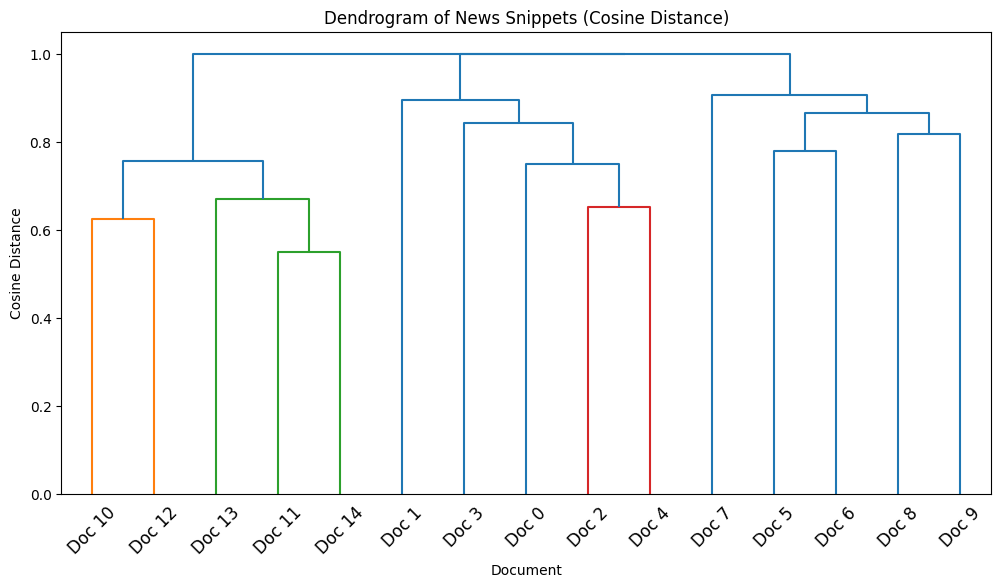

In [4]:
# Cosine distance = 1 - cosine similarity. We compute pairwise cosine distances directly,
# then feed the condensed distance matrix into `linkage` with method='average'
# (Ward's method requires Euclidean distance, so we use 'average' linkage for cosine here).
cosine_dist = pdist(X_tfidf, metric='cosine')

Z = linkage(cosine_dist, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=[f"Doc {i}" for i in range(len(documents))])
plt.title('Dendrogram of News Snippets (Cosine Distance)')
plt.xlabel('Document')
plt.ylabel('Cosine Distance')
plt.xticks(rotation=45)
plt.show()


Just like the numeric examples, you should see **3 clean groups** emerge — matching our 3 hidden topics (Sports, Technology, Finance) — purely from word usage patterns, with no manual labeling.

## 5. Cluster and Inspect Results

In [5]:
model = AgglomerativeClustering(n_clusters=3, metric='cosine', linkage='average')
df['cluster'] = model.fit_predict(X_tfidf)

for c in sorted(df['cluster'].unique()):
    print(f"\n--- Cluster {c} ---")
    for text in df[df['cluster'] == c]['text']:
        print(" -", text)



--- Cluster 0 ---
 - The new smartphone has a faster processor and better camera software.
 - The laptop comes with a powerful processor and upgraded software.
 - The tech company released a software update improving camera performance.
 - The app developer launched new software with an improved user interface.
 - The device features a faster chip and improved battery software.

--- Cluster 1 ---
 - The stock market rallied as bank earnings beat investor expectations.
 - Investors watched bank stock prices rise after strong earnings reports.
 - The bank reported higher earnings, boosting investor confidence in the market.
 - Stock prices fell after the bank missed earnings expectations this quarter.
 - The market reacted to bank earnings with a sharp rise in stock prices.

--- Cluster 2 ---
 - The football team won the match after scoring a late goal.
 - The basketball team won the game with a buzzer beater shot.
 - Fans cheered as their team scored the winning goal in the match.
 - T

## 6. What Are the Most Important Words per Cluster?

In [6]:
feature_names = np.array(vectorizer.get_feature_names_out())

for c in sorted(df['cluster'].unique()):
    cluster_docs_idx = df[df['cluster'] == c].index
    avg_tfidf = X_tfidf[cluster_docs_idx].mean(axis=0)
    top_words_idx = avg_tfidf.argsort()[::-1][:6]
    print(f"Cluster {c} top words:", ", ".join(feature_names[top_words_idx]))


Cluster 0 top words: software, processor, faster, new, camera, improved
Cluster 1 top words: bank, earnings, stock, market, prices, expectations
Cluster 2 top words: team, match, goal, winning, won, championship


This gives us an automatic, human-readable topic name for each cluster — e.g. words like *team, goal, match* clearly signal **Sports**, while *stock, earnings, bank* signal **Finance**.

## 7. Real-World Extensions

- Swap in real news headlines (e.g. from an RSS feed or a CSV export) instead of the hardcoded list.
- Try clustering customer support tickets by cosine similarity to auto-group them by issue type.
- Try clustering product descriptions in an e-commerce catalog to auto-suggest categories.
- Compare TF-IDF + cosine distance against using sentence embeddings (e.g. from a pretrained model) for even better topic separation on real-world messy text.
